# Exploratory Data Analysis (EDA)

## Business Understanding

AlphaCare Insurance Solutions (ACIS) aims to optimize marketing investments and improve insurance pricing through data-driven decision making.

The objective of this analysis is to understand customer risk profiles, identify profitable and unprofitable segments, and uncover patterns in claims behavior that can support future hypothesis testing and predictive modeling.

Key business metrics include:

- Loss Ratio = TotalClaims / TotalPremium
- Margin = TotalPremium - TotalClaims

These metrics will help evaluate portfolio profitability and risk across customer, vehicle, and geographic segments.


01_eda.ipynb flow

1. Business Understanding
2. Data Loading
3. Dataset Overview
4. Data Quality Assessment
5. Feature Engineering
6. Data Summarization
7. Univariate Analysis
8. Bivariate & Multivariate Analysis
9. Geographic Analysis
10. Outlier Detection
11. Temporal Trends
12. Business Questions
13. Key Findings

## Import Required Libraries

The following libraries are used for data manipulation, visualization, and statistical exploration.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

The libraries were successfully imported and are ready for exploratory analysis.

## Load Dataset

The dataset contains historical automobile insurance policy and claims information from February 2014 to August 2015.

In [7]:
df = pd.read_csv(
    "../data/raw/MachineLearningRating_v3.txt",
    sep="|",
    low_memory=False
)

### Data Loading Observations

The dataset was successfully loaded into memory. During import, pandas reported mixed data types for a small number of columns. To ensure consistent type inference and avoid chunk-based parsing issues, the dataset was loaded using `low_memory=False`.

These columns will be investigated further during data quality assessment to determine whether type conversion is necessary.

## Dataset Overview

Before performing detailed analysis, we examine the size, structure, and data types of the dataset.

In [8]:
df.shape
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   UnderwrittenCoverID       1000098 non-null  int64  
 1   PolicyID                  1000098 non-null  int64  
 2   TransactionMonth          1000098 non-null  str    
 3   IsVATRegistered           1000098 non-null  bool   
 4   Citizenship               1000098 non-null  str    
 5   LegalType                 1000098 non-null  str    
 6   Title                     1000098 non-null  str    
 7   Language                  1000098 non-null  str    
 8   Bank                      854137 non-null   str    
 9   AccountType               959866 non-null   str    
 10  MaritalStatus             991839 non-null   str    
 11  Gender                    990562 non-null   str    
 12  Country                   1000098 non-null  str    
 13  Province                  1000098 non-

,count,mean,std,min,25%,50%,75%,max
UnderwrittenCoverID,1000098.0,1.048175e+05,6.329371e+04,1.000000e+00,5.514300e+04,9.408300e+04,1.391900e+05,3.011750e+05
PolicyID,1000098.0,7.956682e+03,5.290039e+03,1.400000e+01,4.500000e+03,7.071000e+03,1.107700e+04,2.324600e+04
PostalCode,1000098.0,3.020601e+03,2.649854e+03,1.000000e+00,8.270000e+02,2.000000e+03,4.180000e+03,9.870000e+03
mmcode,999546.0,5.487770e+07,1.360381e+07,4.041200e+06,6.005692e+07,6.005842e+07,6.005842e+07,6.506535e+07
RegistrationYear,1000098.0,2.010225e+03,3.261391e+00,1.987000e+03,2.008000e+03,2.011000e+03,2.013000e+03,2.015000e+03
Cylinders,999546.0,4.046642e+00,2.940201e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,1.000000e+01
cubiccapacity,999546.0,2.466743e+03,4.428006e+02,0.000000e+00,2.237000e+03,2.694000e+03,2.694000e+03,1.288000e+04
kilowatts,999546.0,9.720792e+01,1.939326e+01,0.000000e+00,7.500000e+01,1.110000e+02,1.110000e+02,3.090000e+02
NumberOfDoors,999546.0,4.019250e+00,4.683144e-01,0.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,6.000000e+00
CustomValueEstimate,220456.0,2.255311e+05,5.645157e+05,2.000000e+04,1.350000e+05,2.200000e+05,2.800000e+05,2.655000e+07


### Dataset Overview Findings

The dataset contains 1,000,098 policy-level observations and 52 variables covering customer information, vehicle characteristics, geographic attributes, policy details, premiums, and claims.

The dataset consists primarily of categorical features, with a smaller set of numerical variables used to quantify risk and profitability.

Several fields contain substantial missing values, particularly vehicle-related attributes and financial indicators. These observations will guide the data-cleaning strategy used in later stages of the project.

The large sample size provides a strong foundation for reliable statistical analysis and predictive modeling.

## Data Quality Assessment

Data quality is evaluated by examining missing values, duplicate records, and data type consistency.

In [10]:
missing_pct = (
    df.isnull()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_pct[missing_pct > 0]

(df.isnull().mean()*100)\
.sort_values(ascending=False)

df.duplicated().sum()

np.int64(0)

In [50]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

from src.eda_utils import calculate_loss_ratio
from src.eda_utils import missing_value_summary

calculate_loss_ratio(df)

missing_value_summary(df).head()

,MissingCount,MissingPercent
NumberOfVehiclesInFleet,1000098,100.00
CrossBorder,999400,99.93
CustomValueEstimate,779642,77.96
WrittenOff,641901,64.18
Rebuilt,641901,64.18


### Findings

#### Missing Values

The dataset contains missing values in several variables. Missingness is concentrated in specific columns rather than being uniformly distributed across the dataset.

Variables such as `Bank`, `AccountType`, `Gender`, vehicle-related attributes, and financial fields should be investigated further to determine whether imputation, removal, or alternative handling strategies are appropriate.

Additionally, some variables may contain extremely high percentages of missing values, reducing their usefulness for subsequent analysis and predictive modeling.

#### Duplicate Records

The duplicate check returned **0 duplicate observations**, indicating that each row represents a unique policy-period transaction.

This suggests that no duplicate records need to be removed before proceeding with exploratory analysis.

#### Data Quality Conclusion

Overall, the dataset appears structurally sound, with no duplicate observations and manageable missing-value challenges. Missing data handling strategies will be documented and addressed in later stages of the project before statistical testing and model development.

## Data Consistency Checks

Before creating business KPIs, it is important to investigate whether financial variables contain unexpected values such as negative premiums or negative claim amounts. Such observations may represent refunds, adjustments, or accounting corrections and could affect profitability metrics.

In [11]:
(df["TotalPremium"] < 0).sum()

np.int64(288)

In [12]:
(df["TotalClaims"] < 0).sum()

np.int64(5)

### Findings

#### Negative Premium Values

The analysis identified **288 records with negative premium values**. In an insurance context, negative premiums may represent policy cancellations, premium refunds, adjustments, accounting corrections, or reversed transactions rather than standard premium payments.

Although these records represent a very small proportion of the dataset, they should be considered when calculating profitability metrics such as Loss Ratio and Margin.

#### Negative Claim Values

Only **5 records contain negative claim amounts**. These observations are likely associated with claim reversals, recoveries, adjustments, or administrative corrections.

Given the extremely small number of negative claim records relative to the overall dataset size, they are unlikely to materially impact portfolio-level conclusions.

#### Data Consistency Conclusion

The presence of a small number of negative financial transactions is consistent with real-world insurance operations. These records will be retained during exploratory analysis to preserve the integrity of the historical portfolio. However, they should be reviewed carefully during feature engineering and predictive modeling to ensure they do not distort model performance.

## Feature Engineering

To evaluate portfolio profitability and risk, two key business metrics are created:

### Loss Ratio
Loss Ratio measures the relationship between claims and premiums and is a standard insurance profitability metric.

Loss Ratio = TotalClaims / TotalPremium

### Margin
Margin represents the profit contribution of each policy.

Margin = TotalPremium − TotalClaims

These metrics will be used throughout the analysis to compare risk across provinces, vehicle types, and customer segments.

In [13]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)

df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

### Findings

The Loss Ratio and Margin variables were successfully created and will serve as the primary business KPIs for evaluating profitability and risk exposure throughout the exploratory analysis.

A Loss Ratio below 1 generally indicates profitable business, while values above 1 suggest claims exceed premium income. Margin provides a direct measure of profit contribution at the policy level.

In [14]:
overall_loss_ratio = (
    df["TotalClaims"].sum()
    /
    df["TotalPremium"].sum()
)

overall_loss_ratio

np.float64(1.0477452570332206)

### Findings

#### Overall Portfolio Loss Ratio

The overall portfolio Loss Ratio is approximately **1.05 (104.77%)**.

This means that for every 1 unit of premium collected, the company paid approximately 1.05 units in claims during the observation period.

Since the Loss Ratio exceeds 1, total claims are greater than total premium income, indicating that the portfolio was **unprofitable** over the analyzed period when considering claims alone.

This result suggests that certain customer segments, vehicle categories, or geographic regions may be generating disproportionately high claim costs. Identifying these high-risk segments is therefore a key objective of the subsequent analysis.

#### Business Implications

A portfolio Loss Ratio above 100% indicates potential pressure on underwriting profitability. Further segmentation analysis by Province, VehicleType, Gender, and other risk factors is necessary to identify areas where pricing adjustments or targeted marketing strategies may improve overall portfolio performance.

## Data Summarization

This section summarizes the key numerical variables used throughout the analysis. Understanding the central tendency, variability, and range of these variables helps identify potential risk drivers and unusual observations that may influence profitability.

In [15]:
summary_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "SumInsured"
]

df[summary_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalPremium,1000098.0,61.905496,2.302845e+02,-782.576754,0.0,2.178333,21.929825,6.528260e+04
TotalClaims,1000098.0,64.861190,2.384075e+03,-12002.412281,0.0,0.000000,0.000000,3.930921e+05
CustomValueEstimate,220456.0,225531.129942,5.645157e+05,20000.000000,135000.0,220000.000000,280000.000000,2.655000e+07
SumInsured,1000098.0,604172.732589,1.508332e+06,0.010000,5000.0,7500.000000,250000.000000,1.263620e+07


### Findings

The descriptive statistics reveal substantial variability across the insurance portfolio, particularly in the financial variables.

#### Total Premium

The average premium is approximately **61.91**, while the median premium is only **2.18**. This large difference indicates a highly right-skewed distribution, where most policies pay relatively small premiums and a small number of policies contribute exceptionally large premium amounts.

The presence of negative premium values (minimum = -782.58) confirms the existence of premium adjustments, refunds, or policy reversals within the dataset.

#### Total Claims

The average claim amount is approximately **64.86**, while both the 25th percentile and median are equal to **0**. Furthermore, the 75th percentile is also **0**, indicating that the majority of policy records did not generate claims during the observation period.

However, a small number of extremely large claims exist, with a maximum claim amount exceeding **393,000**. This suggests a highly skewed claim distribution where a limited number of high-severity claims contribute significantly to overall portfolio losses.

#### Custom Value Estimate

Vehicle values exhibit considerable variation across the portfolio. The median vehicle value is approximately **220,000**, while the maximum recorded value exceeds **26.5 million**.

This large range indicates the presence of high-value vehicles that may contribute disproportionately to claim severity and insurance risk.

#### Sum Insured

The Sum Insured variable also displays substantial variability. While the median insured amount is approximately **7,500**, some policies are insured for amounts exceeding **12.6 million**.

The significant gap between typical and maximum insured values suggests that policy risk exposure varies considerably across customers.

#### Overall Interpretation

The descriptive statistics indicate that the portfolio contains highly skewed financial variables with substantial outliers. This pattern is common in insurance datasets, where a relatively small number of high-cost claims and high-value policies account for a large share of total financial exposure.

These findings justify further investigation through distribution analysis, outlier detection, and segmentation by geographic, customer, and vehicle characteristics.

## Univariate Analysis

This section examines the distribution of key numerical variables to understand their shape, spread, and potential outliers.

Because insurance data often exhibits strong skewness, visual inspection is essential for identifying unusual patterns that may influence profitability and risk assessment.

### Distribution of Total Premium

Understanding the distribution of premium payments helps evaluate the overall pricing structure of the portfolio.

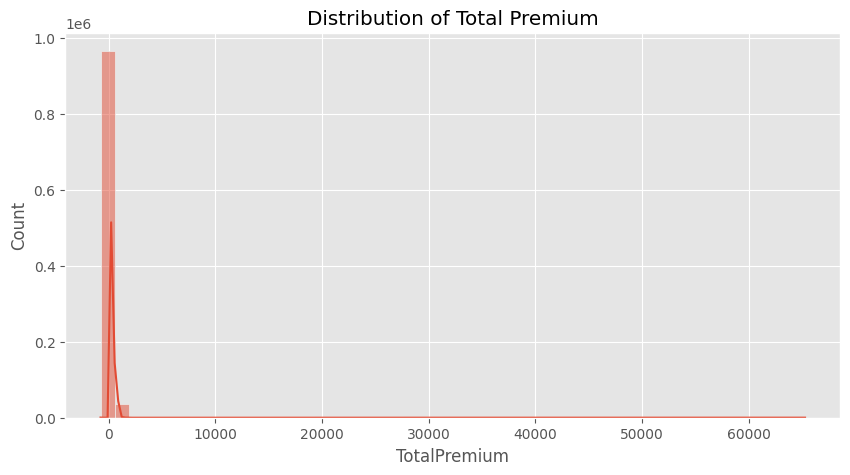

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["TotalPremium"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Premium")
plt.show()

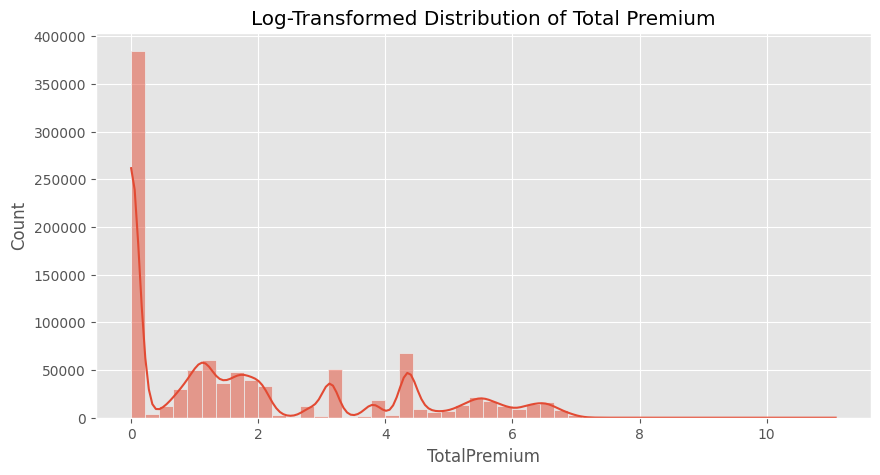

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["TotalPremium"].clip(lower=0)),
    bins=50,
    kde=True
)

plt.title("Log-Transformed Distribution of Total Premium")
plt.show()

### Findings

The distribution of **TotalPremium** is highly right-skewed, with the majority of policies concentrated at relatively low premium values and a small number of policies generating exceptionally large premiums.

A substantial spike near zero indicates that many records have very low premium amounts, while a limited number of observations extend to extremely high values. This creates a long right tail and suggests the presence of premium outliers.

The large difference between the median premium (2.18) and the maximum premium (65,282.60) further confirms the existence of extreme values.

From a business perspective, this indicates that a relatively small subset of policies contributes disproportionately to premium revenue. These high-premium policies may represent specialized coverage, high-value assets, commercial vehicles, or other elevated-risk insurance products.

Because the distribution is heavily skewed, additional visualizations such as box plots and log-transformed distributions may provide a clearer view of the underlying premium patterns.

### Distribution of Total Claims

Claim amounts are one of the most important indicators of insurance risk. Understanding their distribution helps identify claim frequency patterns and the presence of high-severity loss events.

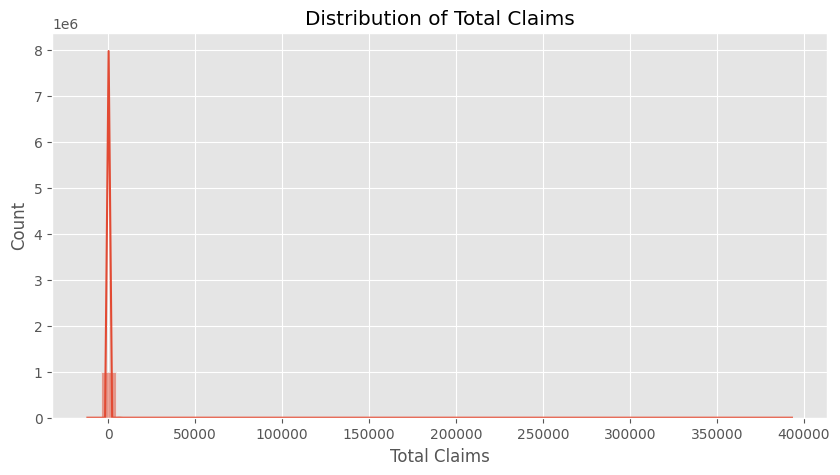

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["TotalClaims"],
    bins=50,
    kde=True
)

plt.title("Distribution of Total Claims")
plt.xlabel("Total Claims")
plt.ylabel("Count")

plt.show()

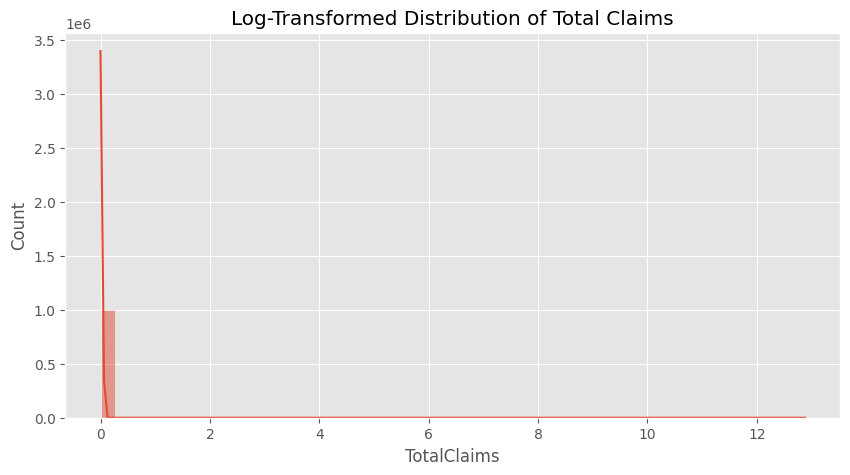

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df["TotalClaims"].clip(lower=0)),
    bins=50,
    kde=True
)

plt.title("Log-Transformed Distribution of Total Claims")

plt.show()

### Distribution of Non-Zero Claims

The previous visualization revealed a highly zero-inflated distribution, where the majority of policy records generated no claims during the observation period.

To better understand claim severity among policies that actually experienced losses, the analysis is repeated using only records with positive claim amounts.

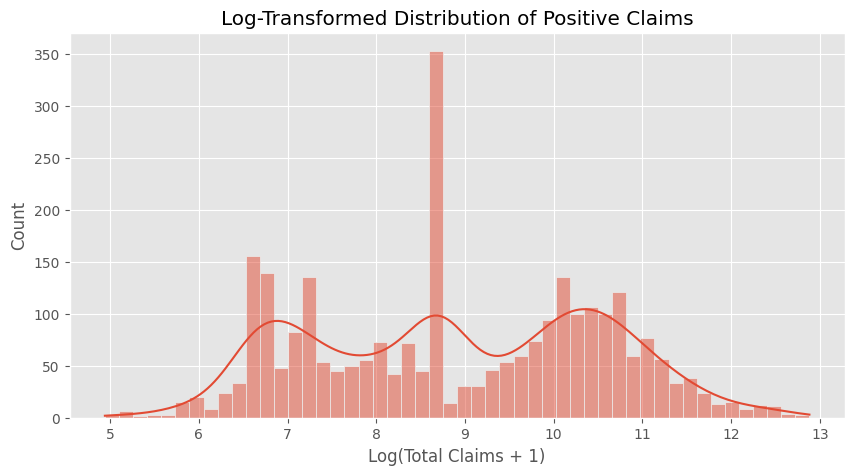

In [21]:
claims_positive = df[df["TotalClaims"] > 0]

plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(claims_positive["TotalClaims"]),
    bins=50,
    kde=True
)

plt.title("Log-Transformed Distribution of Positive Claims")
plt.xlabel("Log(Total Claims + 1)")
plt.ylabel("Count")

plt.show()

### Findings

The distribution of positive claim amounts reveals a much richer structure than was visible in the original claim distribution.

After removing zero-claim observations and applying a logarithmic transformation, the distribution exhibits multiple distinct peaks rather than a single bell-shaped curve. This suggests that claim severity may not be generated from a single underlying process.

Several clusters of claim amounts appear to exist:

- A lower-value claim segment representing relatively small losses.
- A concentrated middle segment characterized by a narrow range of claim amounts.
- A higher-value segment consisting of larger and more severe claim events.

The presence of multiple peaks indicates that different claim types, policy categories, vehicle classes, or coverage structures may be contributing to claim severity in different ways.

### Business Implications

These findings suggest that claim severity is heterogeneous across the portfolio. Rather than treating all claims as a single population, future analyses should investigate whether claim behavior differs systematically across:

- Vehicle types
- Cover categories
- Provinces
- Vehicle makes and models
- Customer segments

Understanding these segments may help improve pricing strategies and risk differentiation.

### Modeling Implications

The multimodal nature of the distribution suggests that claim severity may be influenced by multiple underlying risk groups. This observation supports the use of segmentation-based analysis and may justify more sophisticated modeling approaches in later stages of the project.

## Claim Frequency Analysis

The previous analysis showed that most observations have zero claim amounts. To quantify this phenomenon, we calculate the proportion of policies that generated at least one claim during the observation period.

In [22]:
claim_frequency = (
    (df["TotalClaims"] > 0).mean() * 100
)

claim_frequency

np.float64(0.2787726802773328)

### Findings

The portfolio exhibits a claim frequency of approximately **27.88%**.

This indicates that roughly **28 out of every 100 policy-period observations generated at least one claim**, while the remaining **72% did not produce any claims during the observation period**.

This finding is consistent with the earlier distribution analysis, where the majority of claim records were concentrated at zero.

### Business Interpretation

The portfolio appears to be characterized by relatively infrequent claim events. However, when claims do occur, they can be substantial in magnitude, as evidenced by the extreme claim values observed in the descriptive statistics and outlier analysis.

This suggests that overall portfolio risk is influenced by both:

- Claim Frequency (how often claims occur)
- Claim Severity (how costly claims become)

The combination of moderate claim frequency and highly variable claim severity is typical of insurance portfolios and highlights the importance of identifying customer segments associated with higher claim costs.

## Outlier Detection

Insurance datasets frequently contain extreme observations due to high-value assets, severe accidents, or catastrophic claim events.

Outlier analysis helps identify observations that differ substantially from the majority of the portfolio and may influence profitability metrics, statistical summaries, and predictive model performance.

Box plots are used to visualize the spread of key financial variables and detect extreme values.

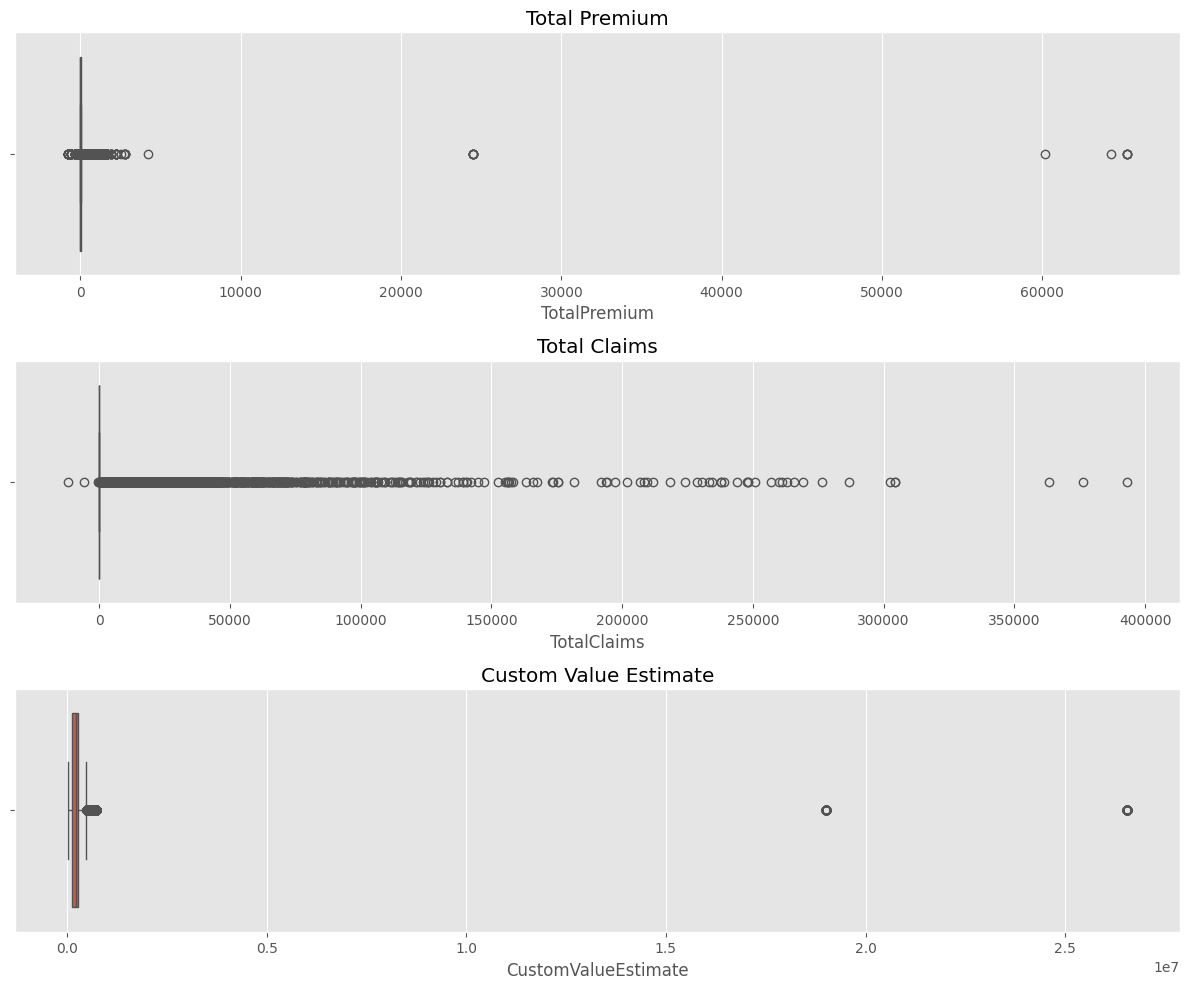

In [23]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(12,10)
)

sns.boxplot(
    x=df["TotalPremium"],
    ax=axes[0]
)

axes[0].set_title("Total Premium")

sns.boxplot(
    x=df["TotalClaims"],
    ax=axes[1]
)

axes[1].set_title("Total Claims")

sns.boxplot(
    x=df["CustomValueEstimate"].dropna(),
    ax=axes[2]
)

axes[2].set_title("Custom Value Estimate")

plt.tight_layout()

plt.show()

### Findings

The box plots reveal substantial outliers across all three financial variables: **TotalPremium**, **TotalClaims**, and **CustomValueEstimate**.

#### Total Premium

The distribution of Total Premium is highly right-skewed. Most policies have relatively low premium values, while a small number of policies generate exceptionally large premiums.

Several extreme premium observations exceed 20,000, with the largest values approaching 65,000. These observations may represent commercial policies, specialized coverage products, or high-risk insured assets.

#### Total Claims

Total Claims exhibits the most extreme outlier behavior in the portfolio. While the majority of policy records have claim amounts near zero, a small number of claims extend beyond 300,000, with the largest claim approaching 400,000.

A small number of negative claim values are also present, likely representing claim reversals, adjustments, or administrative corrections identified during the data consistency assessment.

These high-severity claims contribute disproportionately to overall portfolio losses and help explain the portfolio Loss Ratio exceeding 100%.

#### Custom Value Estimate

Custom Value Estimate also contains significant outliers. Most vehicles fall within a moderate valuation range, but a limited number of assets have estimated values exceeding several million.

The largest observed vehicle value exceeds 26.5 million, suggesting the presence of high-value commercial, luxury, or specialized vehicles within the portfolio.

#### Business Interpretation

The presence of extreme outliers across all three variables is consistent with real-world insurance data, where a relatively small number of policies and claim events account for a large share of financial exposure.

These observations appear to represent genuine business events rather than obvious data errors and will therefore be retained during exploratory analysis. However, their influence should be carefully considered during statistical testing and predictive modeling, where transformations or robust modeling techniques may be required.

# Bivariate and Multivariate Analysis

Understanding relationships between premiums, claims, vehicle values, and geographic factors is critical for identifying drivers of risk and profitability.

This section explores interactions among key variables through scatter plots and correlation analysis.

### Relationship Between Total Premium and Total Claims

Premium income and claim costs are the primary drivers of insurance profitability. This visualization explores whether policies with higher premiums tend to generate higher claim amounts.

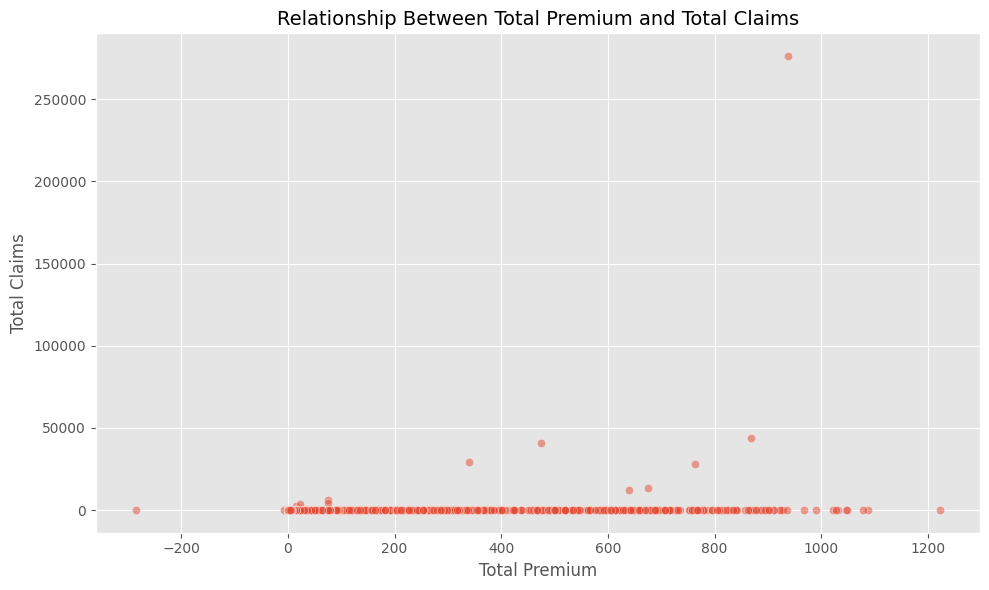

In [24]:
# Create a representative sample for visualization
scatter_sample = df.sample(
    n=5000,
    random_state=42
)

# Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=scatter_sample,
    x="TotalPremium",
    y="TotalClaims",
    alpha=0.5
)

plt.title(
    "Relationship Between Total Premium and Total Claims",
    fontsize=14
)

plt.xlabel("Total Premium")
plt.ylabel("Total Claims")

plt.tight_layout()
plt.show()

### Findings

The scatter plot reveals a highly imbalanced insurance portfolio where the majority of policyholders generate little or no claim activity despite paying premiums.

A dense concentration of observations is visible along the zero-claims line, indicating that most customers pay premiums without submitting claims during the observation period. These policies represent the most profitable segment of the portfolio.

Several high-severity claim events are visible as isolated points far above the main cluster. One extreme observation generated a claim amount exceeding 275,000 while paying a premium below 1,000, resulting in an exceptionally high loss ratio.

The visualization shows no strong linear relationship between premium amounts and claim costs. Customers paying higher premiums do not necessarily generate larger claims, suggesting that additional risk factors influence claim behavior.

### Business Interpretation

The portfolio appears to follow a typical insurance pattern characterized by low-frequency, high-severity losses. While most policies are profitable, a relatively small number of severe claims account for a substantial portion of total losses.

This observation highlights the importance of identifying customer, vehicle, and geographic characteristics associated with high-severity claims.

### Premium and Claims by Postal Code

Geographic location may influence insurance risk through differences in traffic conditions, crime rates, infrastructure, and customer demographics.

This analysis compares average premium and claim amounts across postal codes.

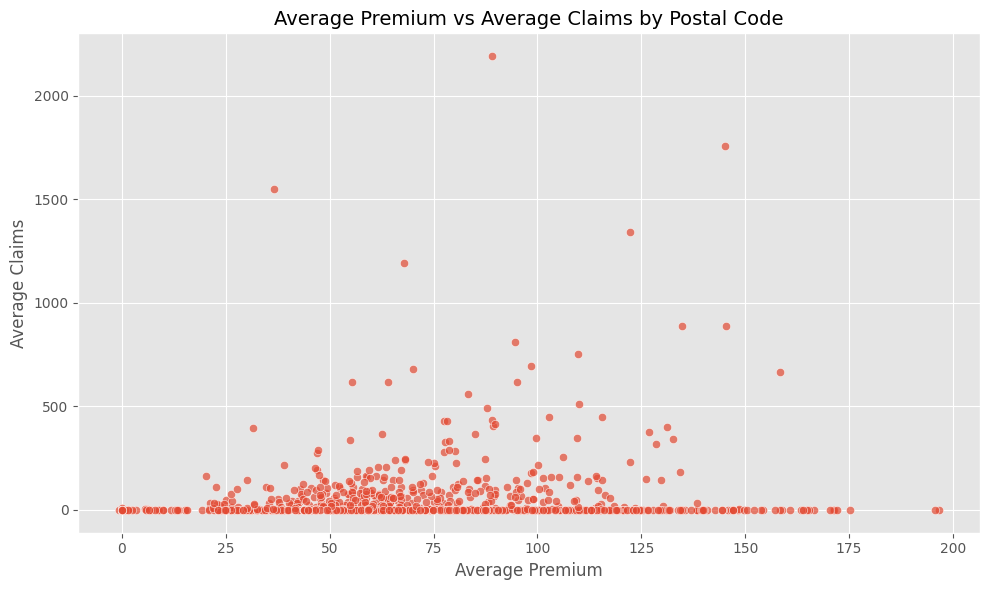

In [25]:
# Aggregate metrics at postal code level
postalcode_summary = (
    df.groupby("PostalCode")
      .agg(
          AvgPremium=("TotalPremium", "mean"),
          AvgClaims=("TotalClaims", "mean")
      )
      .reset_index()
)

# Plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=postalcode_summary,
    x="AvgPremium",
    y="AvgClaims",
    alpha=0.7
)

plt.title(
    "Average Premium vs Average Claims by Postal Code",
    fontsize=14
)

plt.xlabel("Average Premium")
plt.ylabel("Average Claims")

plt.tight_layout()
plt.show()

### Findings

The postal code analysis reveals significant geographic variation in insurance performance.

Most postal codes exhibit relatively low average claim amounts regardless of average premium levels, suggesting stable and profitable underwriting performance across much of the portfolio.

However, several postal codes emerge as clear outliers, displaying average claim costs that substantially exceed the premiums collected within those areas. These locations represent potential concentrations of elevated insurance risk.

The absence of a strong positive relationship between average premiums and average claims suggests that geographic pricing may not fully reflect historical loss experience in all regions.

### Business Interpretation

Geographic location appears to be an important risk factor within the portfolio. Certain postal codes consistently generate higher claim costs than others, indicating potential influences such as traffic density, theft rates, accident frequency, environmental hazards, or local socioeconomic conditions.

These findings support the inclusion of geographic variables in future risk modeling and provide justification for province- and postal-code-level hypothesis testing in subsequent project phases.

## Correlation Analysis

Correlation analysis provides a quantitative assessment of relationships among key financial variables.

Understanding these relationships helps identify factors that may influence insurance risk, profitability, and future predictive model performance.

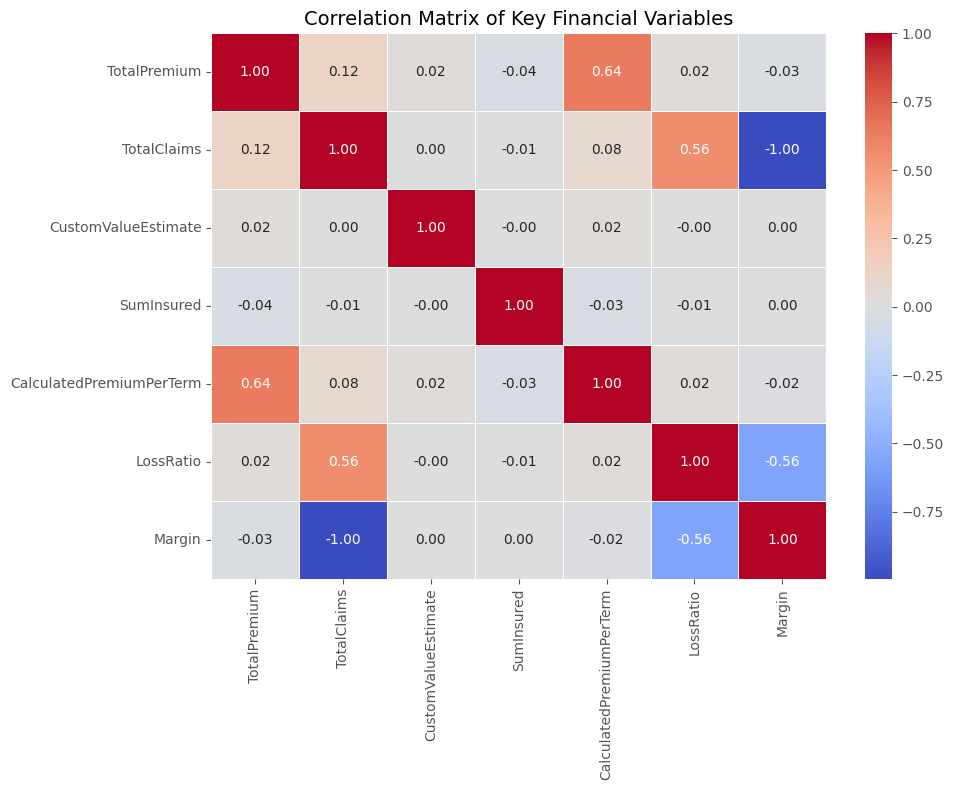

In [26]:
# Select numerical variables for correlation analysis
correlation_features = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate",
    "SumInsured",
    "CalculatedPremiumPerTerm",
    "LossRatio",
    "Margin"
]

# Compute correlation matrix
correlation_matrix = (
    df[correlation_features]
    .corr()
)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Key Financial Variables",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Findings

The correlation matrix provides insight into relationships among the portfolio's key financial variables.

A perfect negative correlation exists between Total Claims and Margin, confirming that increasing claim costs directly reduce profitability. This relationship is expected because claim payments represent a direct expense to the insurer.

Total Premium and Calculated Premium Per Term exhibit a moderately strong positive correlation, indicating that total premium income is largely driven by the premium calculated at the policy level.

Loss Ratio shows a positive relationship with Total Claims and a negative relationship with Margin, demonstrating that claim activity is the primary driver of underwriting performance.

Interestingly, Total Premium and Total Claims display only a weak positive correlation. This finding aligns with the scatter plot analysis and suggests that premium size alone is not a strong predictor of future claim costs.

Custom Value Estimate and Sum Insured exhibit relatively weak relationships with the other financial variables, indicating that asset value alone does not fully explain premium levels, claim behavior, or profitability outcomes within the portfolio.

### Modeling Implications

The weak relationship between premiums and claims suggests that predictive models will need to incorporate additional explanatory variables such as vehicle characteristics, geographic factors, and customer attributes.

The perfect correlation between Margin and Total Claims also indicates that care should be taken when selecting features for predictive modeling to avoid redundancy and multicollinearity issues.

# Geographic Trends Analysis

This section investigates how insurance performance varies across provinces by comparing premiums, claims, profitability, cover types, and vehicle makes.

Understanding geographic variation can help identify regional risk concentrations and opportunities for improved pricing strategies.

In [27]:
province_summary = (
    df.groupby("Province")
      .agg(
          TotalPremium=("TotalPremium", "sum"),
          TotalClaims=("TotalClaims", "sum")
      )
)

province_summary["LossRatio"] = (
    province_summary["TotalClaims"] /
    province_summary["TotalPremium"]
)

province_summary.sort_values(
    "LossRatio",
    ascending=False
)

,TotalPremium,TotalClaims,LossRatio
Province,,,
Gauteng,2.405377e+07,2.939415e+07,1.222018
KwaZulu-Natal,1.320908e+07,1.430138e+07,1.082693
Western Cape,9.806559e+06,1.038977e+07,1.059472
North West,7.490508e+06,5.920250e+06,0.790367
Mpumalanga,2.836292e+06,2.044675e+06,0.720897
Free State,5.213632e+05,3.549223e+05,0.680758
Limpopo,1.537324e+06,1.016477e+06,0.661199
Eastern Cape,2.140104e+06,1.356427e+06,0.633813
Northern Cape,3.165581e+05,8.949051e+04,0.282699


In [28]:
province_premium = (
    df.groupby("Province")["TotalPremium"]
      .sum()
      .sort_values(ascending=False)
)

In [29]:
province_cover = (
    pd.crosstab(
        df["Province"],
        df["CoverType"]
    )
)

In [30]:
top_makes = (
    df["make"]
      .value_counts()
      .head(10)
      .index
)

province_make = (
    df[df["make"].isin(top_makes)]
      .groupby(["Province", "make"])
      .size()
      .unstack(fill_value=0)
)

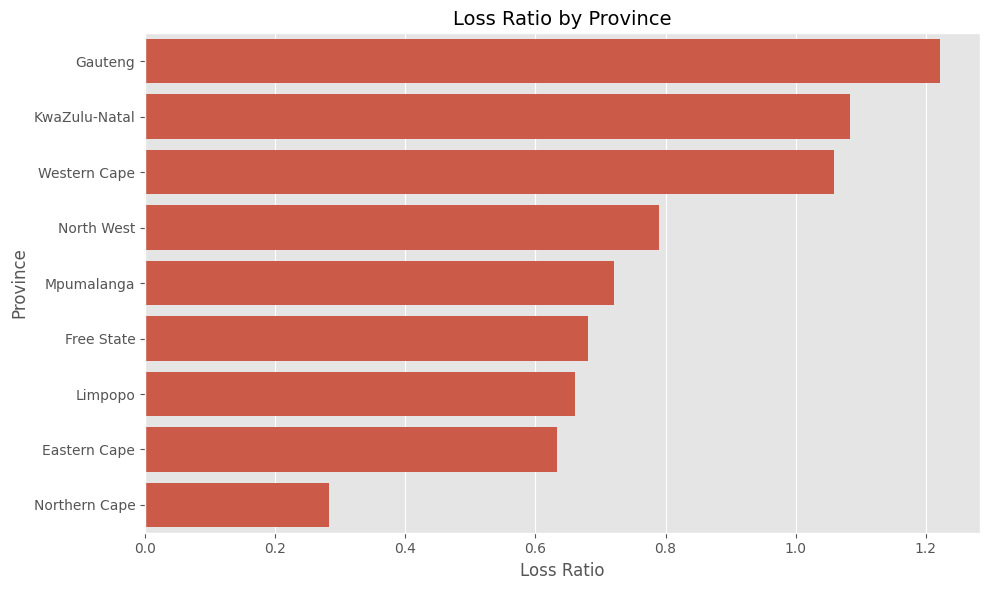

In [31]:
# Sort provinces by Loss Ratio
province_summary_sorted = (
    province_summary
    .sort_values("LossRatio", ascending=False)
)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=province_summary_sorted.reset_index(),
    x="LossRatio",
    y="Province"
)

plt.title(
    "Loss Ratio by Province",
    fontsize=14
)

plt.xlabel("Loss Ratio")
plt.ylabel("Province")

plt.tight_layout()
plt.show()

### Findings

The provincial analysis reveals substantial variation in underwriting performance across South Africa.

Three provinces exhibit Loss Ratios greater than 1.0, indicating that claim costs exceeded premium income during the observation period:

- Gauteng recorded the highest Loss Ratio (1.22).
- KwaZulu-Natal recorded a Loss Ratio of 1.08.
- Western Cape recorded a Loss Ratio of 1.06.

These provinces generated underwriting losses because claims paid exceeded premiums collected.

In contrast, Northern Cape recorded the lowest Loss Ratio (0.28), indicating substantially lower claim costs relative to premium income and stronger portfolio profitability.

Most remaining provinces maintained Loss Ratios below 1.0, suggesting that premium income was sufficient to cover claim expenses.

### Business Interpretation

The findings suggest that geographic location is an important determinant of insurance risk within the portfolio.

Gauteng, KwaZulu-Natal, and Western Cape appear to represent the highest-risk regions from an underwriting perspective. These provinces may experience greater traffic density, higher accident frequency, elevated theft rates, or other factors contributing to increased claim activity.

Northern Cape appears to be the most profitable province, generating substantially lower claims relative to premium income.

These results provide evidence that province-level factors should be considered in future pricing, risk segmentation, and predictive modeling initiatives.

In [32]:
province_summary.sort_values(
    "TotalPremium",
    ascending=False
)

,TotalPremium,TotalClaims,LossRatio
Province,,,
Gauteng,2.405377e+07,2.939415e+07,1.222018
KwaZulu-Natal,1.320908e+07,1.430138e+07,1.082693
Western Cape,9.806559e+06,1.038977e+07,1.059472
North West,7.490508e+06,5.920250e+06,0.790367
Mpumalanga,2.836292e+06,2.044675e+06,0.720897
Eastern Cape,2.140104e+06,1.356427e+06,0.633813
Limpopo,1.537324e+06,1.016477e+06,0.661199
Free State,5.213632e+05,3.549223e+05,0.680758
Northern Cape,3.165581e+05,8.949051e+04,0.282699


### Additional Observation

The three provinces generating the largest premium volumes are also among the provinces with the highest Loss Ratios.

This indicates that a significant portion of the portfolio's underwriting losses may be concentrated within the insurer's largest markets.

Consequently, even small improvements in pricing accuracy or risk management within these provinces could have a substantial impact on overall portfolio profitability.

In [33]:
vehicle_summary = (
    df.groupby("VehicleType")
      .agg(
          TotalPremium=("TotalPremium", "sum"),
          TotalClaims=("TotalClaims", "sum")
      )
)

vehicle_summary["LossRatio"] = (
    vehicle_summary["TotalClaims"] /
    vehicle_summary["TotalPremium"]
)

vehicle_summary.sort_values(
    "LossRatio",
    ascending=False
)

,TotalPremium,TotalClaims,LossRatio
VehicleType,,,
Heavy Commercial,4.609479e+05,7.504746e+05,1.628112
Medium Commercial,3.922746e+06,4.119867e+06,1.050251
Passenger Vehicle,5.664202e+07,5.937207e+07,1.048198
Light Commercial,2.604975e+05,6.045250e+04,0.232066
Bus,5.824474e+04,7.996535e+03,0.137292


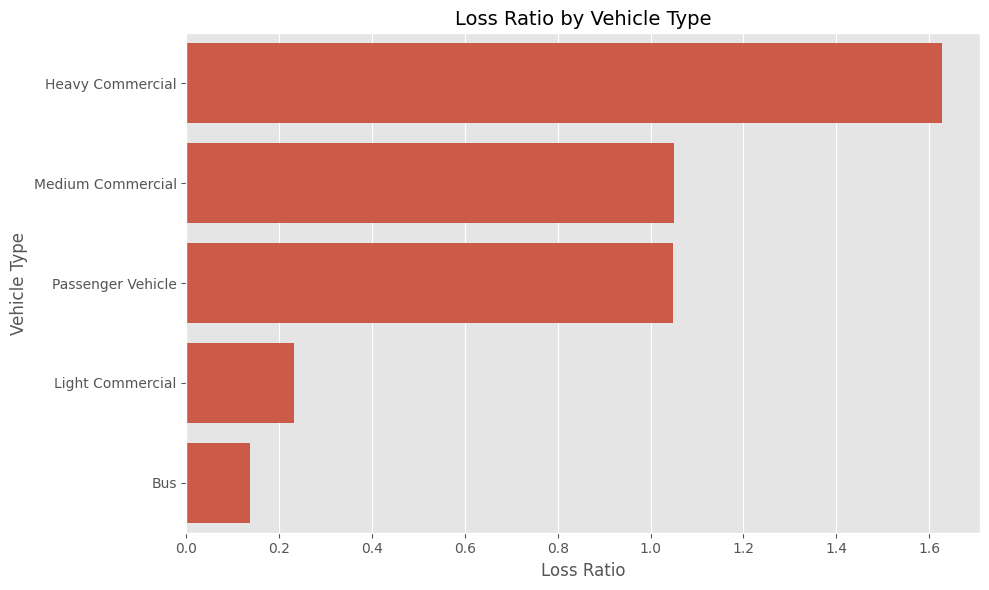

In [34]:
vehicle_summary_sorted = (
    vehicle_summary
    .sort_values("LossRatio", ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=vehicle_summary_sorted.reset_index(),
    x="LossRatio",
    y="VehicleType"
)

plt.title(
    "Loss Ratio by Vehicle Type",
    fontsize=14
)

plt.xlabel("Loss Ratio")
plt.ylabel("Vehicle Type")

plt.tight_layout()
plt.show()

### Findings

Vehicle type exhibits substantial variation in underwriting performance across the portfolio.

Heavy Commercial vehicles recorded the highest Loss Ratio (1.63), indicating that claim costs exceeded premium income by approximately 63%. This category appears to be the least profitable segment within the portfolio.

Medium Commercial vehicles and Passenger Vehicles also generated Loss Ratios above 1.0, with values of 1.05 and 1.05 respectively. These vehicle categories produced underwriting losses as total claims exceeded premiums collected.

In contrast, Light Commercial vehicles recorded a Loss Ratio of 0.23, while Buses recorded the lowest Loss Ratio of 0.14. These segments generated substantially lower claim costs relative to premium income and appear significantly more profitable.

### Business Interpretation

The results suggest that vehicle type is a critical driver of insurance risk.

Heavy Commercial vehicles may experience greater exposure to accidents, cargo-related risks, longer travel distances, and higher repair costs, contributing to elevated claim severity and frequency.

Passenger Vehicles represent the largest portion of the portfolio and also exhibit a Loss Ratio greater than 1.0. Consequently, even small improvements in underwriting, pricing, or risk management within this category could have a meaningful impact on overall profitability.

Light Commercial vehicles and Buses appear to represent lower-risk segments and may warrant further investigation to identify characteristics associated with their stronger performance.

### Portfolio Impact

Although Heavy Commercial vehicles have the highest Loss Ratio, Passenger Vehicles contribute the largest share of premium income and claim costs within the portfolio.

As a result, Passenger Vehicles likely have the greatest influence on overall portfolio profitability despite having a lower Loss Ratio than Heavy Commercial vehicles.

This finding highlights the importance of considering both risk level and business volume when evaluating underwriting performance.

In [35]:
gender_summary = (
    df.groupby("Gender")
      .agg(
          TotalPremium=("TotalPremium", "sum"),
          TotalClaims=("TotalClaims", "sum")
      )
)

gender_summary["LossRatio"] = (
    gender_summary["TotalClaims"] /
    gender_summary["TotalPremium"]
)

gender_summary.sort_values(
    "LossRatio",
    ascending=False
)

,TotalPremium,TotalClaims,LossRatio
Gender,,,
Not specified,5.920275e+07,6.271410e+07,1.059311
Male,1.580143e+06,1.396704e+06,0.883910
Female,3.044806e+05,2.502461e+05,0.821879


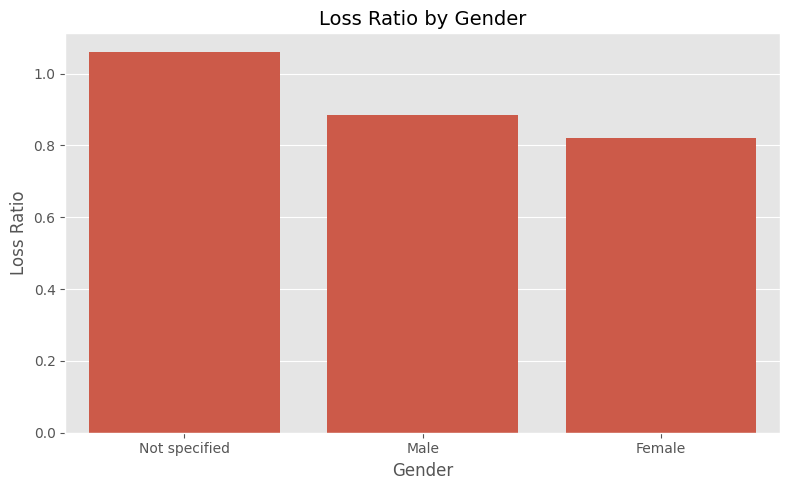

In [36]:
gender_summary_sorted = (
    gender_summary
    .sort_values("LossRatio", ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=gender_summary_sorted.reset_index(),
    x="Gender",
    y="LossRatio"
)

plt.title(
    "Loss Ratio by Gender",
    fontsize=14
)

plt.xlabel("Gender")
plt.ylabel("Loss Ratio")

plt.tight_layout()
plt.show()

### Findings

The analysis reveals relatively small differences in Loss Ratio across gender categories.

The "Not Specified" category recorded the highest Loss Ratio (1.06), indicating that claims slightly exceeded premium income within this segment.

Among records with available gender information, Male policyholders recorded a Loss Ratio of 0.88, while Female policyholders recorded a slightly lower Loss Ratio of 0.82.

Both Male and Female groups maintained Loss Ratios below 1.0, suggesting that premium income exceeded claim costs within these segments.

### Business Interpretation

The results provide limited evidence that gender is a major driver of portfolio profitability.

However, interpretation should be approached with caution because the overwhelming majority of observations fall within the "Not Specified" category.

The large volume of missing gender information reduces confidence in comparisons between Male and Female policyholders and may limit the usefulness of gender as a predictive feature in future analyses.

Additional investigation into data completeness would be required before drawing strong conclusions regarding gender-related risk differences.

# Temporal Trend Analysis

Insurance risk may change over time due to economic conditions, seasonal effects, regulatory changes, or shifts in customer behavior.

This section examines how premiums, claims, and claim frequency evolved throughout the observation period.

Monthly Premiums and Claims

In [37]:
# Convert transaction date
df["TransactionMonth"] = pd.to_datetime(
    df["TransactionMonth"]
)

monthly_summary = (
    df.groupby("TransactionMonth")
      .agg(
          TotalPremium=("TotalPremium", "sum"),
          TotalClaims=("TotalClaims", "sum")
      )
)

monthly_summary

,TotalPremium,TotalClaims
TransactionMonth,,
2013-10-01,3.710635e+02,0.000000e+00
2013-11-01,2.130747e+04,5.058508e+04
2013-12-01,4.248475e+04,9.283386e+03
2014-01-01,5.408520e+04,1.243686e+04
2014-02-01,6.078844e+04,6.298931e+04
2014-03-01,9.857719e+04,3.227850e+05
2014-04-01,2.342743e+05,3.068636e+05
2014-05-01,3.759117e+05,5.180427e+05
2014-06-01,4.862194e+05,5.045364e+05


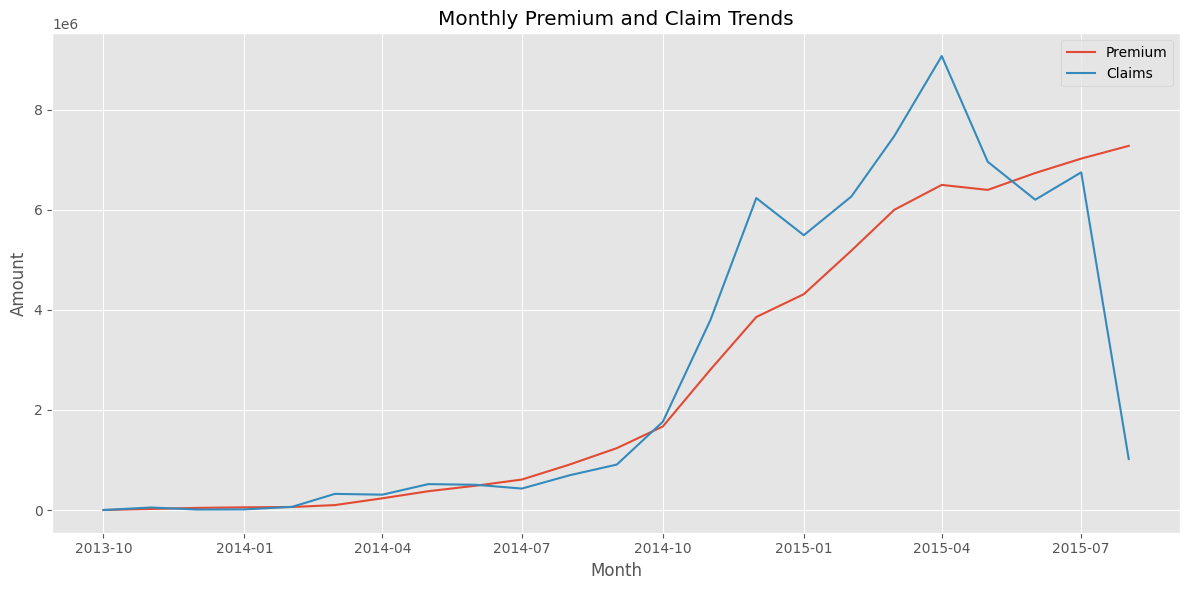

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_summary.index,
    monthly_summary["TotalPremium"],
    label="Premium"
)

plt.plot(
    monthly_summary.index,
    monthly_summary["TotalClaims"],
    label="Claims"
)

plt.title(
    "Monthly Premium and Claim Trends"
)

plt.xlabel("Month")
plt.ylabel("Amount")

plt.legend()

plt.tight_layout()
plt.show()

### Findings

The monthly premium and claim trends reveal substantial changes in portfolio performance over the observation period.

During the early stages of the portfolio (late 2013 through mid-2014), both premium income and claim costs remained relatively low. Beginning in mid-2014, however, the portfolio experienced rapid growth, reflected by a sharp increase in both premiums collected and claims incurred.

A particularly important pattern emerges between late 2014 and mid-2015, where total claims consistently exceeded total premiums. This period corresponds to a sustained underwriting deficit, indicating that claim costs were growing faster than premium revenue.

The largest imbalance occurred around April 2015, when monthly claims peaked at approximately 9 million while premiums remained significantly lower. This suggests a period of elevated portfolio risk and reduced profitability.

A sharp decline in claims is observed during the final month of the dataset. However, this decrease should be interpreted cautiously, as it may reflect reporting delays or incomplete claim development rather than a genuine reduction in risk.

### Business Interpretation

The portfolio experienced rapid expansion during the observation period, but growth was accompanied by increasing claim costs.

The prolonged period in which claims exceeded premiums suggests that pricing strategies may not have fully captured underlying risk during the expansion phase. These findings highlight the importance of continuous monitoring of portfolio profitability and periodic review of underwriting assumptions.

Monthly Claim Frequency

In [39]:
claim_frequency_monthly = (
    df.groupby("TransactionMonth")
      .apply(
          lambda x: (x["TotalClaims"] > 0).mean()
      )
      .reset_index(name="ClaimFrequency")
)

claim_frequency_monthly.head()

,TransactionMonth,ClaimFrequency
0,2013-10-01,0.000000
1,2013-11-01,0.001672
2,2013-12-01,0.002007
3,2014-01-01,0.001095
4,2014-02-01,0.002910


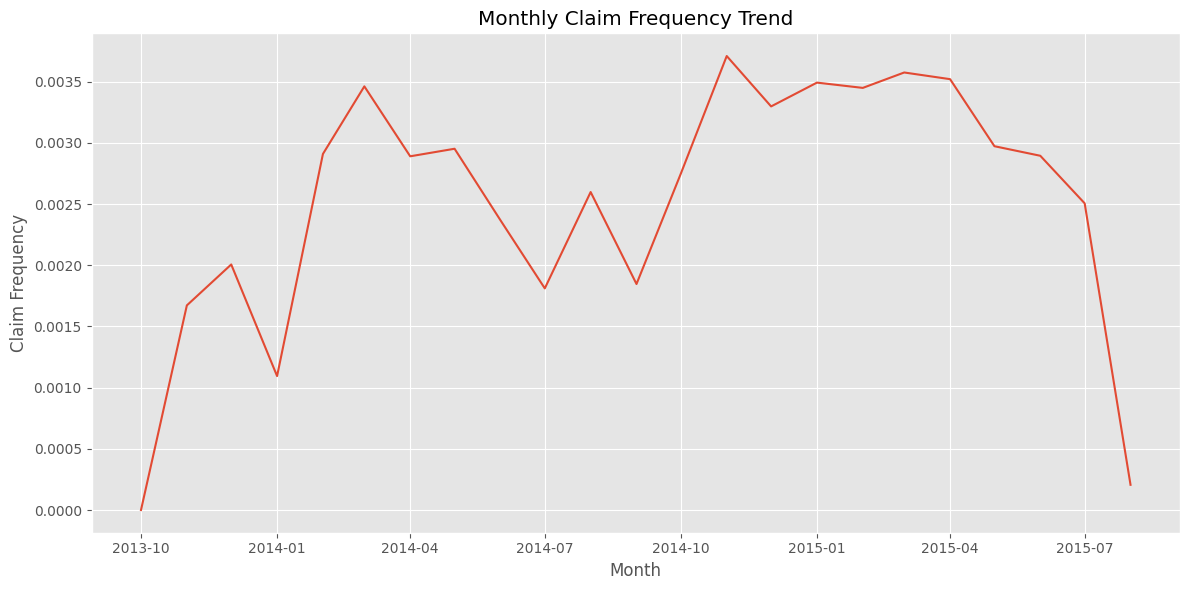

In [40]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=claim_frequency_monthly,
    x="TransactionMonth",
    y="ClaimFrequency"
)

plt.title(
    "Monthly Claim Frequency Trend"
)

plt.xlabel("Month")
plt.ylabel("Claim Frequency")

plt.tight_layout()
plt.show()

### Findings

The claim frequency analysis provides additional insight into how risk evolved throughout the observation period.

During the early months of the portfolio, claim frequency exhibited substantial volatility. This behavior is expected in smaller portfolios where a limited number of claim events can significantly affect monthly rates.

Beginning in late 2014, claim frequency increased and remained elevated for several consecutive months. This sustained period of higher claim occurrence coincides with the period in which total claims consistently exceeded premium income.

Unlike the monetary claim trend, which can be influenced by a few large losses, the claim frequency trend indicates that risk increased broadly across the portfolio through a greater number of claim events.

The final month again shows a dramatic decline in claim frequency. Given the corresponding decline in total claims, this observation likely reflects incomplete reporting rather than an immediate improvement in portfolio performance.

### Business Interpretation

The results suggest that the deterioration in underwriting performance during late 2014 and early 2015 was driven not only by claim severity but also by an increase in claim frequency.

This indicates that policyholders were filing claims more frequently during this period, increasing pressure on portfolio profitability. Future analysis should investigate whether geographic, vehicle-related, or customer-specific factors contributed to this rise in claim activity.

# Vehicle Make and Model Risk Analysis

Vehicle characteristics can significantly influence claim behavior due to differences in repair costs, theft risk, accident frequency, and vehicle usage patterns.

This section identifies the vehicle makes and models associated with the highest and lowest claim amounts.

Highest Claim Vehicle Makes

In [41]:
make_claims = (
    df.groupby("make")
      .agg(
          TotalClaims=("TotalClaims", "sum"),
          TotalPremium=("TotalPremium", "sum")
      )
)

make_claims["LossRatio"] = (
    make_claims["TotalClaims"] /
    make_claims["TotalPremium"]
)

make_claims.sort_values(
    "TotalClaims",
    ascending=False
).head(10)

,TotalClaims,TotalPremium,LossRatio
make,,,
TOYOTA,5.174611e+07,4.994567e+07,1.036048
MERCEDES-BENZ,2.938695e+06,2.764734e+06,1.062922
VOLKSWAGEN,1.839180e+06,1.416877e+06,1.298052
CMC,1.323616e+06,9.574460e+05,1.382444
GOLDEN JOURNEY,1.246583e+06,1.462989e+06,0.852079
AUDI,1.021004e+06,3.762743e+05,2.713456
IVECO,7.558930e+05,5.261262e+05,1.436714
C.A.M,6.957082e+05,6.075631e+05,1.145080
BMW,4.814972e+05,2.427652e+05,1.983386


Highest Claim Vehicle Models

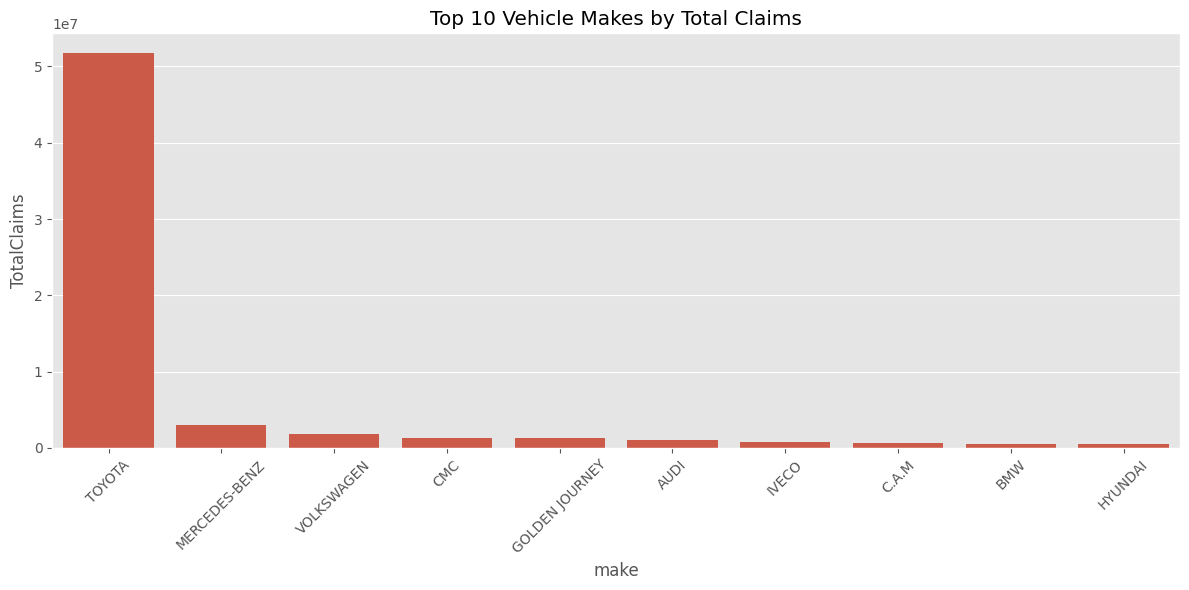

In [42]:
top_makes = (
    make_claims
    .sort_values("TotalClaims", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_makes.reset_index(),
    x="make",
    y="TotalClaims"
)

plt.title(
    "Top 10 Vehicle Makes by Total Claims"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Findings

The vehicle make analysis reveals a highly concentrated claim distribution across manufacturers.

Toyota vehicles account for the largest share of total claims by a substantial margin, generating claim costs exceeding 50 million. This value is significantly greater than the claim volumes observed for all other vehicle makes in the portfolio.

Mercedes-Benz and Volkswagen rank as the second and third highest contributors to total claims, although their claim volumes remain considerably lower than Toyota's.

The remaining vehicle makes contribute relatively small proportions of the total claim burden, indicating that claim costs are heavily concentrated among a limited number of manufacturers.

### Business Interpretation

At first glance, Toyota appears to be associated with the highest insurance risk within the portfolio. However, total claim volume alone does not necessarily indicate higher risk.

The observed pattern may simply reflect Toyota's larger representation within the insured vehicle population. If Toyota vehicles account for a significant proportion of all policies, higher total claims would be expected due to greater exposure.

Therefore, total claims should be interpreted alongside exposure measures such as policy counts, premium volume, average claim cost, and loss ratio.

### Modeling Implications

Vehicle make appears to be an informative feature for risk modeling and should be retained for future predictive analysis.

However, subsequent modeling efforts should focus on normalized risk metrics such as:

- Average claim amount per vehicle make
- Claim frequency by vehicle make
- Loss ratio by vehicle make

These metrics provide a more accurate representation of underlying risk than total claim volume alone.

Vehicle Makes with Highest and Lowest Average Claim Amounts

In [43]:
make_avg_claim = (
    df[df["TotalClaims"] > 0]
    .groupby("make")
    .agg(
        AverageClaim=("TotalClaims", "mean"),
        ClaimCount=("TotalClaims", "count")
    )
)

make_avg_claim = make_avg_claim[
    make_avg_claim["ClaimCount"] >= 20
]

make_avg_claim.sort_values(
    "AverageClaim",
    ascending=False
).head(10)

,AverageClaim,ClaimCount
make,,
GOLDEN JOURNEY,46169.723522,27
IVECO,31495.539656,24
AUDI,30939.506443,33
VOLKSWAGEN,30150.485741,61
CMC,30082.171180,44
C.A.M,25769.636543,27
MERCEDES-BENZ,22960.559974,128
TOYOTA,22331.508098,2318
BMW,19259.886014,25


In [44]:
make_avg_claim.sort_values(
    "AverageClaim",
    ascending=True
).head(10)

,AverageClaim,ClaimCount
make,,
JINBEI,15490.435805,22
BMW,19259.886014,25
TOYOTA,22331.508098,2318
MERCEDES-BENZ,22960.559974,128
C.A.M,25769.636543,27
CMC,30082.171180,44
VOLKSWAGEN,30150.485741,61
AUDI,30939.506443,33
IVECO,31495.539656,24


### Findings

The analysis of average claim amounts reveals substantial variation across vehicle manufacturers.

Golden Journey vehicles recorded the highest average claim amount (46,169.72), significantly exceeding all other vehicle makes in the portfolio. IVECO, AUDI, VOLKSWAGEN, and CMC also exhibited relatively high average claim severities, each exceeding 30,000 per claim on average.

At the opposite end of the spectrum, JINBEI vehicles recorded the lowest average claim amount (15,490.44), followed by BMW and TOYOTA.

Interestingly, although Toyota generated the highest total claim volume within the portfolio, its average claim amount is considerably lower than many other vehicle makes. This indicates that Toyota's large total claim cost is likely driven by portfolio exposure rather than unusually severe claims.

### Business Interpretation

The results suggest that vehicle make influences claim severity and should be considered during underwriting and risk pricing.

Luxury brands such as AUDI and MERCEDES-BENZ exhibit relatively high average claim costs, which may reflect higher repair expenses, more expensive replacement parts, and increased vehicle values.

Commercial manufacturers such as GOLDEN JOURNEY and IVECO appear to generate particularly costly claims, potentially due to larger vehicle sizes, specialized repair requirements, or higher operational exposure.

The contrast between Toyota's dominant total claim volume and its moderate average claim amount highlights the importance of distinguishing between exposure-driven risk and severity-driven risk when evaluating insurance portfolios.

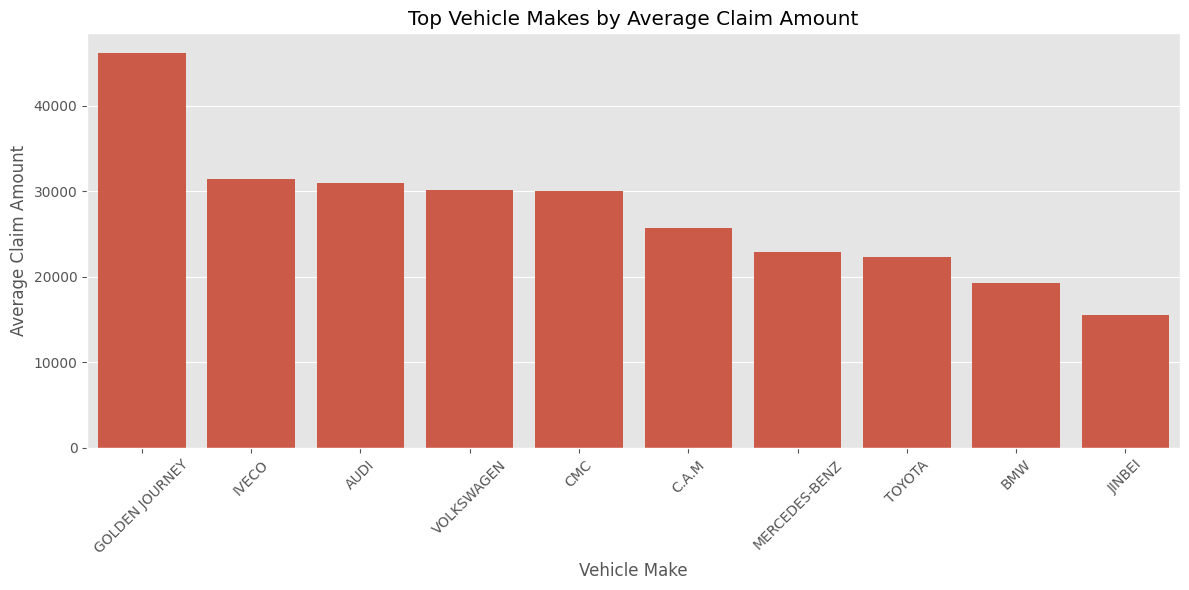

In [45]:
top_avg_claims = (
    make_avg_claim
    .sort_values("AverageClaim", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_avg_claims.reset_index(),
    x="make",
    y="AverageClaim"
)

plt.title(
    "Top Vehicle Makes by Average Claim Amount"
)

plt.xlabel("Vehicle Make")
plt.ylabel("Average Claim Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Findings

The average claim analysis reveals a substantially different risk profile from the total claim analysis.

Golden Journey vehicles recorded the highest average claim amount at approximately 46,170, making them the most severe vehicle category when claim events occur.

IVECO, AUDI, VOLKSWAGEN, and CMC also exhibit high average claim severities, with average payouts exceeding 30,000 per claim.

In contrast, Toyota and Mercedes-Benz, despite generating the largest total claim volumes in the portfolio, exhibit considerably lower average claim amounts. Toyota's average claim amount is approximately 22,332, while Mercedes-Benz averages approximately 22,961 per claim.

This indicates that Toyota's dominance in total claims is largely attributable to portfolio exposure rather than unusually costly individual claim events.

### Business Interpretation

The distinction between total claim volume and average claim severity is critical for insurance pricing and risk assessment.

High-volume vehicle makes such as Toyota contribute significantly to overall portfolio losses because of the number of insured vehicles rather than exceptionally expensive claims.

Conversely, vehicle makes such as Golden Journey and IVECO generate fewer claims but substantially higher claim severities when losses occur.

These findings suggest that underwriting decisions should account for both:

- Claim Frequency (how often claims occur)
- Claim Severity (how costly claims become)

A vehicle make associated with infrequent but expensive claims may require different pricing strategies than a vehicle make associated with frequent but lower-cost claims.

### Modeling Implications

The results support the inclusion of vehicle make as an important predictor in future risk models.

Furthermore, separating claim frequency and claim severity during predictive modeling may improve forecasting accuracy and provide more actionable underwriting insights.

# Highest average claim models  

In [46]:
model_claims = (
    df[df["TotalClaims"] > 0]
    .groupby("Model")
    .agg(
        AverageClaim=("TotalClaims", "mean"),
        ClaimCount=("TotalClaims", "count")
    )
)

model_claims = model_claims[
    model_claims["ClaimCount"] >= 20
]

In [47]:
# Highest average claim models
model_claims.sort_values(
    "AverageClaim",
    ascending=False
).head(10)

,AverageClaim,ClaimCount
Model,,
50 C15V 15 F/C P/V,35736.884921,21
AMANDLA 2.2,32529.616858,34
QUANTUM 2.5 D-4D SESFIKILE 16s,29072.315308,266
SPRINTER 416 CDI HI-ROOF F/C P/V,28710.750337,26
AVANZA 1.5 SX,27943.194908,39
INYATHI,27261.037429,23
QUANTUM 2.7 SESFIKILE 16s,24099.011847,500
SPRINTER 515 CDi HI-ROOF F/C P/V,23984.217828,37
QUANTUM 2.7 SESFIKILE 14s,21956.827741,454


# Lowest average claim models

In [48]:
# Lowest average claim models
model_claims.sort_values(
    "AverageClaim",
    ascending=True
).head(10)

,AverageClaim,ClaimCount
Model,,
HAISE 2.2i,15490.435805,22
QUANTUM 2.5 D-4D 14 SEAT,15946.917331,84
QUANTUM 2.5 D-4D SESFIKILE 15s,18781.531969,27
HiACE SUPER 16 F/Lift,18931.820223,173
QUANTUM 2.7 SESFIKILE 15s,20065.200200,574
HiACE SIYAYA,20568.519766,84
QUANTUM 2.7 SESFIKILE 14s,21956.827741,454
SPRINTER 515 CDi HI-ROOF F/C P/V,23984.217828,37
QUANTUM 2.7 SESFIKILE 16s,24099.011847,500


### Findings

The vehicle model analysis reveals considerable variation in average claim severity across specific vehicle models.

The highest average claim amounts were observed for:

- 50 C15V 15 F/C P/V (35,737)
- AMANDLA 2.2 (32,530)
- QUANTUM 2.5 D-4D SESFIKILE 16s (29,072)
- SPRINTER 416 CDI HI-ROOF F/C P/V (28,711)
- AVANZA 1.5 SX (27,943)

At the lower end of the severity spectrum, the following models recorded the lowest average claim amounts:

- HAISE 2.2i (15,490)
- QUANTUM 2.5 D-4D 14 SEAT (15,947)
- QUANTUM 2.5 D-4D SESFIKILE 15s (18,782)
- HiACE SUPER 16 F/Lift (18,932)
- QUANTUM 2.7 SESFIKILE 15s (20,065)

The results demonstrate that claim severity varies considerably even among models belonging to similar vehicle categories.

### Business Interpretation

Vehicle model appears to be a stronger indicator of claim severity than vehicle make alone.

Differences in vehicle usage, passenger capacity, repair costs, replacement parts, and operational environments may contribute to the observed variation in average claim costs.

These findings suggest that model-level information should be retained as an important predictor for future risk modeling and underwriting decisions.

# Conclusion

This exploratory data analysis provided a comprehensive assessment of the insurance portfolio, focusing on data quality, risk characteristics, profitability, and potential drivers of claim behavior.

The analysis revealed that the portfolio operates with an overall Loss Ratio slightly above 1.0, indicating that claim costs marginally exceed premium income during the observation period. Significant differences in risk and profitability were observed across provinces, vehicle types, and vehicle makes, suggesting that geographic and vehicle-related factors play an important role in underwriting performance.

Several variables exhibited highly skewed distributions and extreme outliers, particularly Total Claims, Total Premium, and Custom Value Estimate. These findings highlight the importance of robust statistical techniques and appropriate feature transformations during subsequent modeling stages.

Temporal analysis showed a period of portfolio growth accompanied by increasing claim frequency and claim severity, contributing to deteriorating underwriting performance during late 2014 and early 2015.

Vehicle-level analysis further demonstrated that total claim volume and claim severity capture different aspects of risk. While Toyota vehicles generated the largest total claim amounts due to exposure volume, other vehicle makes and models exhibited substantially higher average claim severities.

Overall, the EDA identified several factors that warrant further statistical investigation and predictive modeling. The insights generated in this notebook provide a strong foundation for hypothesis testing, risk segmentation, and machine learning development in subsequent project tasks.

### Next Steps

- Conduct statistical hypothesis testing to validate observed differences between customer segments.
- Evaluate province-level, postal-code-level, and gender-based risk differences.
- Develop predictive models for claim severity and risk estimation.
- Apply model interpretability techniques to understand the key drivers of insurance risk.